# EDA of work from home burnout prediction 

# importing all the needed libraries

In [257]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.metrics import accuracy_score
import warnings

In [258]:
df = pd.read_csv('work_from_home_burnout_dataset.csv')

In [259]:
df

,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk
0,1,Weekday,9.59,11.86,4,2,0,7.55,91.2,19.17,Low
1,1,Weekend,7.38,10.33,4,1,0,6.69,82.0,29.70,Low
2,1,Weekend,6.31,8.92,1,2,0,8.87,80.6,32.93,Low
3,1,Weekday,8.34,10.70,4,1,1,8.13,70.0,45.47,Low
4,1,Weekend,6.97,9.83,1,2,0,5.85,67.1,51.61,Low
...,...,...,...,...,...,...,...,...,...,...,...
1795,180,Weekend,6.33,8.16,0,4,0,5.59,73.5,31.91,Low
1796,180,Weekend,4.70,7.88,0,4,0,6.69,89.8,26.30,Low
1797,180,Weekend,3.92,6.39,2,1,0,6.77,74.6,34.07,Low
1798,180,Weekday,8.93,11.11,2,5,0,8.28,74.6,38.14,Low


In [260]:
df.shape

(1800, 11)

In [261]:
df.isna().sum()

user_id                 0
day_type                0
work_hours              0
screen_time_hours       0
meetings_count          0
breaks_taken            0
after_hours_work        0
sleep_hours             0
task_completion_rate    0
burnout_score           0
burnout_risk            0
dtype: int64

In [262]:
df.duplicated().sum()

np.int64(0)

In [263]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               1800 non-null   int64  
 1   day_type              1800 non-null   object 
 2   work_hours            1800 non-null   float64
 3   screen_time_hours     1800 non-null   float64
 4   meetings_count        1800 non-null   int64  
 5   breaks_taken          1800 non-null   int64  
 6   after_hours_work      1800 non-null   int64  
 7   sleep_hours           1800 non-null   float64
 8   task_completion_rate  1800 non-null   float64
 9   burnout_score         1800 non-null   float64
 10  burnout_risk          1800 non-null   object 
dtypes: float64(5), int64(4), object(2)
memory usage: 154.8+ KB


In [264]:
df.nunique()

user_id                  180
day_type                   2
work_hours               689
screen_time_hours        785
meetings_count            11
breaks_taken               5
after_hours_work           2
sleep_hours              452
task_completion_rate     520
burnout_score           1603
burnout_risk               3
dtype: int64

In [265]:
df.describe()

,user_id,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score
count,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000
mean,90.500000,6.515117,9.271406,1.941111,3.028889,0.358889,6.996467,72.308556,44.009978
std,51.975162,2.290521,2.409253,1.696178,1.417844,0.479808,1.061740,14.978647,23.881782
min,1.000000,3.000000,4.510000,0.000000,1.000000,0.000000,4.500000,40.000000,2.500000
25%,45.750000,4.430000,7.240000,1.000000,2.000000,0.000000,6.280000,62.300000,25.370000
50%,90.500000,6.445000,9.210000,2.000000,3.000000,0.000000,6.990000,74.500000,39.270000
75%,135.250000,8.510000,11.310000,3.000000,4.000000,1.000000,7.750000,83.700000,58.197500
max,180.000000,12.170000,15.700000,10.000000,5.000000,1.000000,10.800000,107.200000,143.920000


In [266]:
(df['task_completion_rate'] > 100).sum()

np.int64(10)

In [267]:
(df['burnout_score'] > 100).sum()

np.int64(37)

In [268]:
df['task_completion_rate'].skew()

np.float64(-0.4723262324542117)

In [269]:
df['burnout_score'].skew()

np.float64(0.8665361800496677)

In [270]:

# df['task_completion_rate'] = (
#     df['task_completion_rate']
#     .mask(df['task_completion_rate'] > 100)
#     .fillna(df['task_completion_rate'].median())
# )


In [271]:
# df['burnout_score'] = (
#     df['burnout_score']
#     .mask(df['burnout_score'] > 100)
#     .fillna(df['burnout_score'].median())
# )

In [272]:
df.describe()

,user_id,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score
count,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000
mean,90.500000,6.515117,9.271406,1.941111,3.028889,0.358889,6.996467,72.308556,44.009978
std,51.975162,2.290521,2.409253,1.696178,1.417844,0.479808,1.061740,14.978647,23.881782
min,1.000000,3.000000,4.510000,0.000000,1.000000,0.000000,4.500000,40.000000,2.500000
25%,45.750000,4.430000,7.240000,1.000000,2.000000,0.000000,6.280000,62.300000,25.370000
50%,90.500000,6.445000,9.210000,2.000000,3.000000,0.000000,6.990000,74.500000,39.270000
75%,135.250000,8.510000,11.310000,3.000000,4.000000,1.000000,7.750000,83.700000,58.197500
max,180.000000,12.170000,15.700000,10.000000,5.000000,1.000000,10.800000,107.200000,143.920000


In [273]:
df_new = df.copy 

In [274]:
df_new = df.drop("burnout_risk", axis = 1)

In [275]:
df_new

,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score
0,1,Weekday,9.59,11.86,4,2,0,7.55,91.2,19.17
1,1,Weekend,7.38,10.33,4,1,0,6.69,82.0,29.70
2,1,Weekend,6.31,8.92,1,2,0,8.87,80.6,32.93
3,1,Weekday,8.34,10.70,4,1,1,8.13,70.0,45.47
4,1,Weekend,6.97,9.83,1,2,0,5.85,67.1,51.61
...,...,...,...,...,...,...,...,...,...,...
1795,180,Weekend,6.33,8.16,0,4,0,5.59,73.5,31.91
1796,180,Weekend,4.70,7.88,0,4,0,6.69,89.8,26.30
1797,180,Weekend,3.92,6.39,2,1,0,6.77,74.6,34.07
1798,180,Weekday,8.93,11.11,2,5,0,8.28,74.6,38.14


In [276]:
df_new.describe()

,user_id,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score
count,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000
mean,90.500000,6.515117,9.271406,1.941111,3.028889,0.358889,6.996467,72.308556,44.009978
std,51.975162,2.290521,2.409253,1.696178,1.417844,0.479808,1.061740,14.978647,23.881782
min,1.000000,3.000000,4.510000,0.000000,1.000000,0.000000,4.500000,40.000000,2.500000
25%,45.750000,4.430000,7.240000,1.000000,2.000000,0.000000,6.280000,62.300000,25.370000
50%,90.500000,6.445000,9.210000,2.000000,3.000000,0.000000,6.990000,74.500000,39.270000
75%,135.250000,8.510000,11.310000,3.000000,4.000000,1.000000,7.750000,83.700000,58.197500
max,180.000000,12.170000,15.700000,10.000000,5.000000,1.000000,10.800000,107.200000,143.920000


In [277]:
def classify_burnout(score):
    if score < 40:
        return 'Low'
    elif score < 70:
        return 'Moderate'
    else:
        return 'High'

df_new['burnout_level'] = df_new['burnout_score'].apply(classify_burnout)

In [278]:
df_new

,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_level
0,1,Weekday,9.59,11.86,4,2,0,7.55,91.2,19.17,Low
1,1,Weekend,7.38,10.33,4,1,0,6.69,82.0,29.70,Low
2,1,Weekend,6.31,8.92,1,2,0,8.87,80.6,32.93,Low
3,1,Weekday,8.34,10.70,4,1,1,8.13,70.0,45.47,Moderate
4,1,Weekend,6.97,9.83,1,2,0,5.85,67.1,51.61,Moderate
...,...,...,...,...,...,...,...,...,...,...,...
1795,180,Weekend,6.33,8.16,0,4,0,5.59,73.5,31.91,Low
1796,180,Weekend,4.70,7.88,0,4,0,6.69,89.8,26.30,Low
1797,180,Weekend,3.92,6.39,2,1,0,6.77,74.6,34.07,Low
1798,180,Weekday,8.93,11.11,2,5,0,8.28,74.6,38.14,Low


In [279]:
num_cols = df_new.select_dtypes(include=np.number).columns
cat_cols = df_new.select_dtypes(exclude=np.number).columns

In [280]:
num_cols

Index(['user_id', 'work_hours', 'screen_time_hours', 'meetings_count',
       'breaks_taken', 'after_hours_work', 'sleep_hours',
       'task_completion_rate', 'burnout_score'],
      dtype='object')

In [281]:
cat_cols

Index(['day_type', 'burnout_level'], dtype='object')

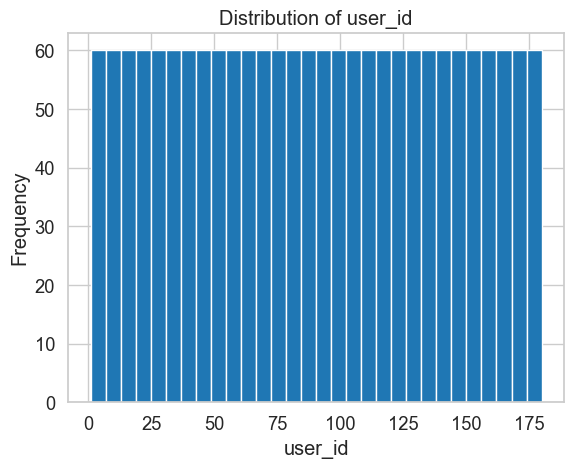

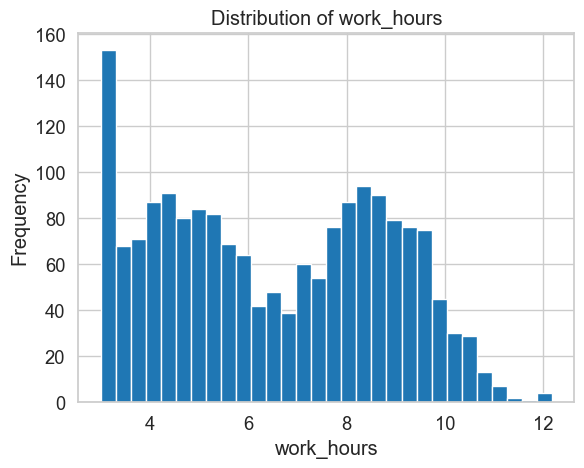

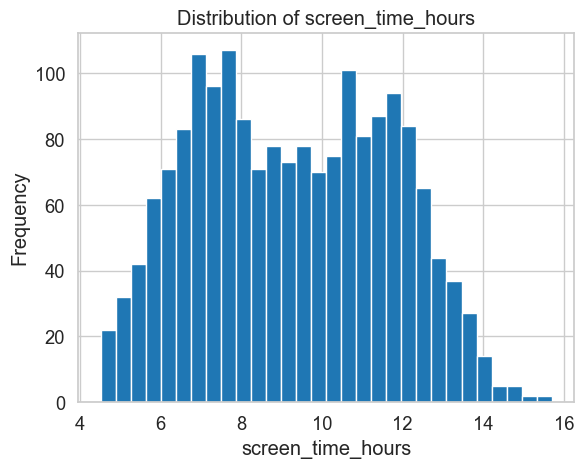

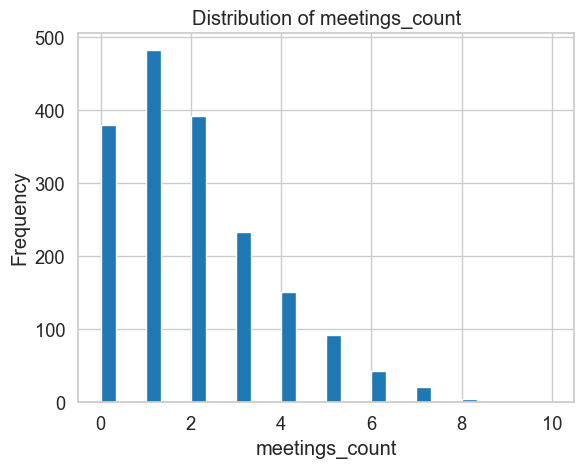

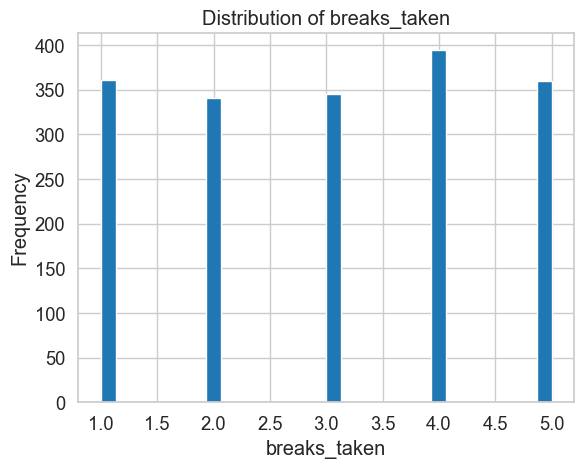

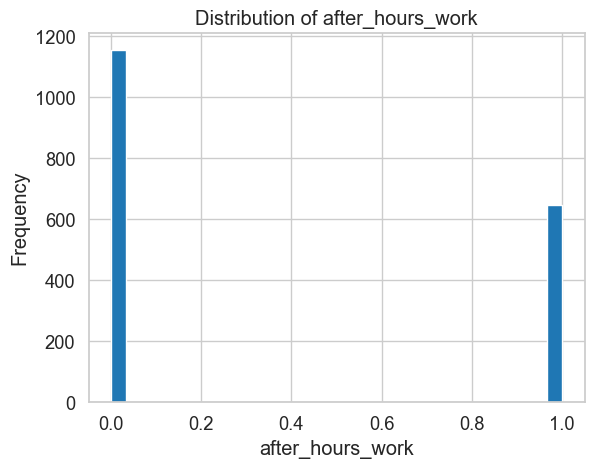

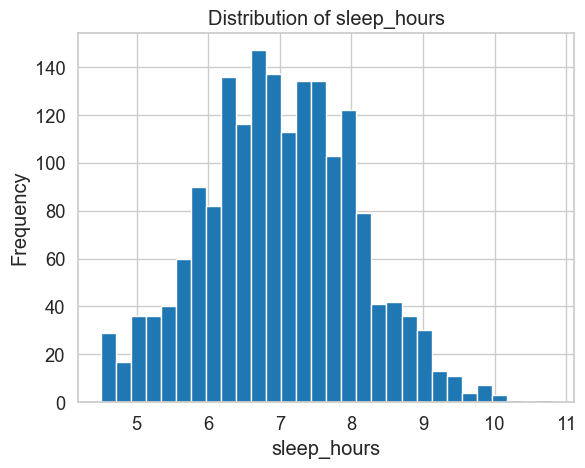

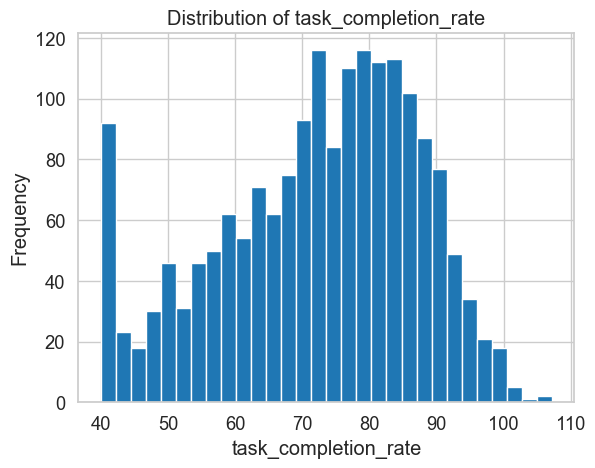

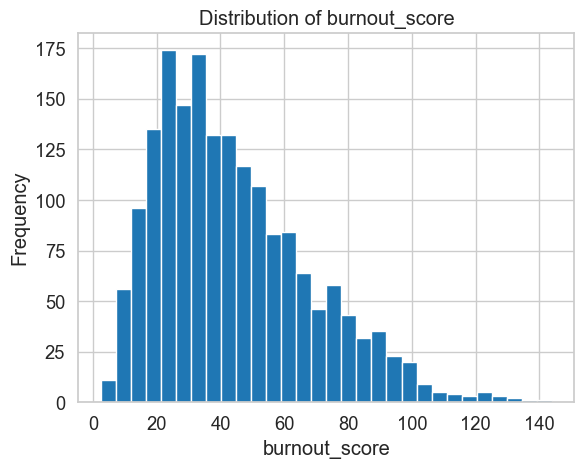

In [282]:
for col in num_cols:
    plt.figure()
    plt.hist(df_new[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


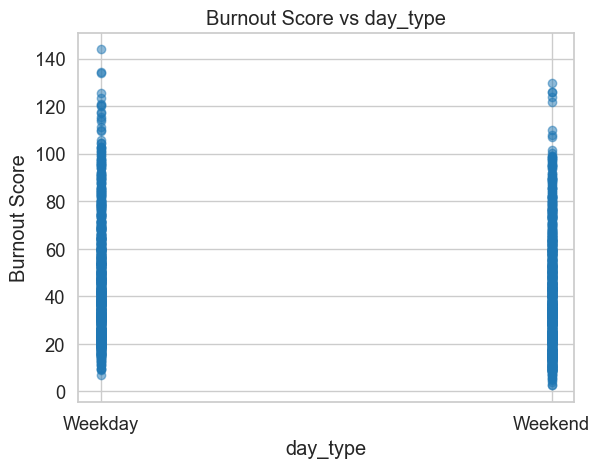

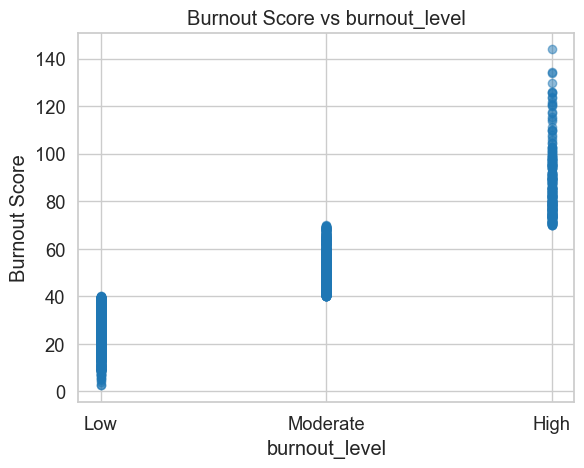

In [283]:

for col in cat_cols:
    plt.figure()
    plt.scatter(df_new[col], df["burnout_score"], alpha=0.5)
    plt.xlabel(col)
    plt.ylabel("Burnout Score")
    plt.title(f"Burnout Score vs {col}")
    plt.show()


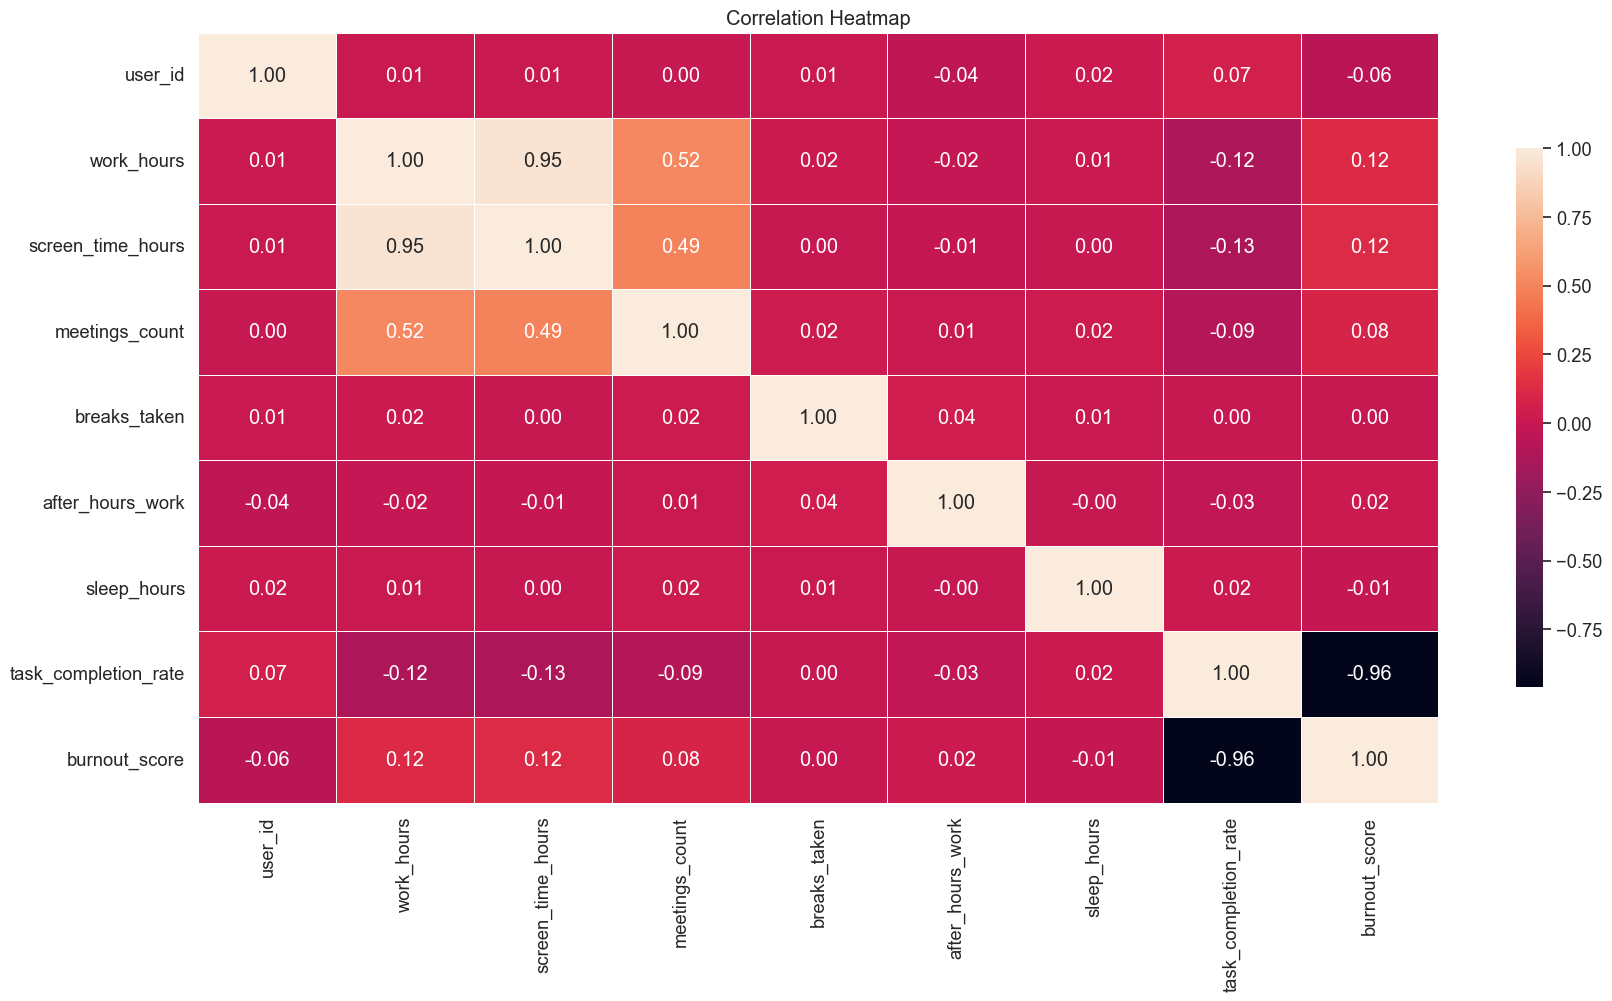

In [284]:

plt.figure(figsize=(20,10))
sns.set_style('whitegrid')
sns.set_context("notebook", font_scale=1.2)

sns.heatmap(
    df_new[num_cols].corr(),
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'shrink':0.7}
)
plt.title('Correlation Heatmap')
plt.show()

In [285]:
df_new.groupby("day_type")["burnout_score"].mean()


day_type
Weekday    46.824189
Weekend    41.341959
Name: burnout_score, dtype: float64

In [286]:
df_new.groupby("after_hours_work")["burnout_score"].mean()


after_hours_work
0    43.689021
1    44.583328
Name: burnout_score, dtype: float64

In [287]:
# skewed values 
skew_before = df_new[num_cols].skew()
# Display skewness values
skew_before.sort_values(ascending=False)

skew_df = pd.DataFrame({
    'Feature': num_cols,
    'Skewness_Before_Imputation': df_new[num_cols].skew().values
})

skew_df.sort_values(by='Skewness_Before_Imputation', ascending=False)

,Feature,Skewness_Before_Imputation
3,meetings_count,0.999487
8,burnout_score,0.866536
5,after_hours_work,0.588853
2,screen_time_hours,0.086803
1,work_hours,0.080079
6,sleep_hours,0.052088
0,user_id,0.000000
4,breaks_taken,-0.052221
7,task_completion_rate,-0.472326


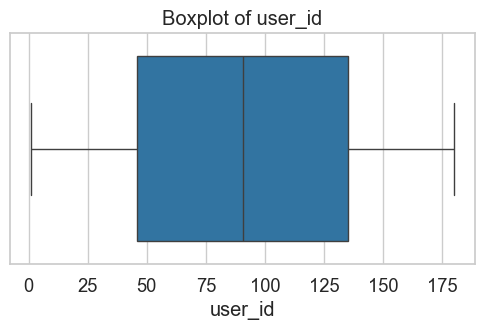

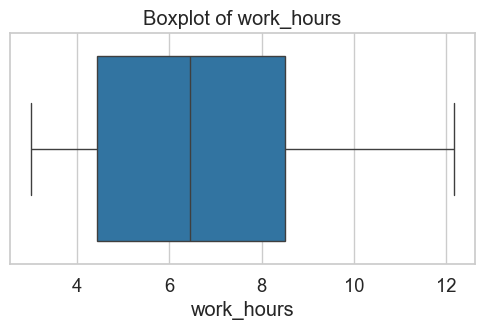

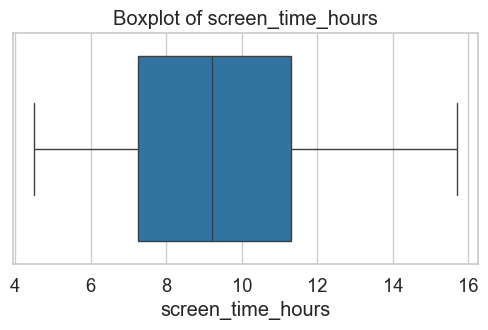

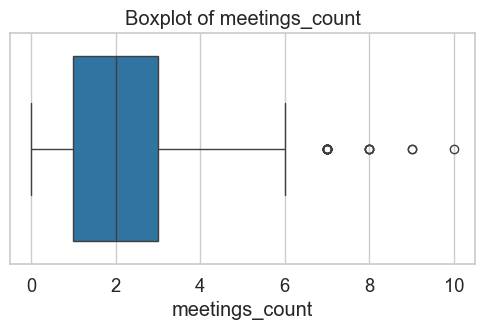

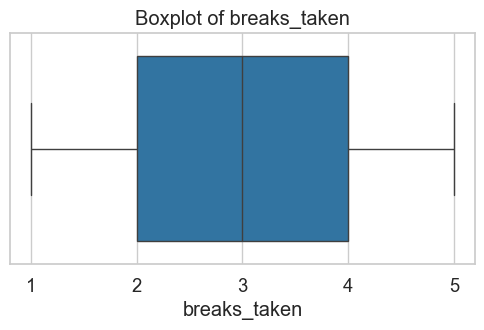

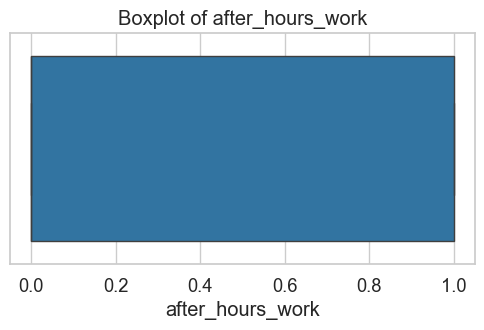

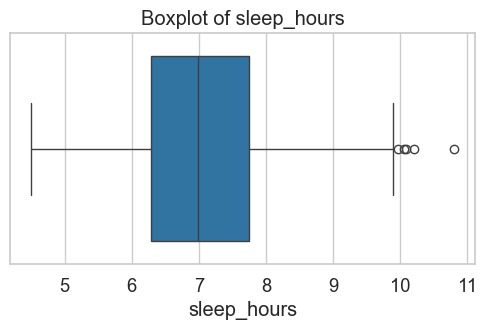

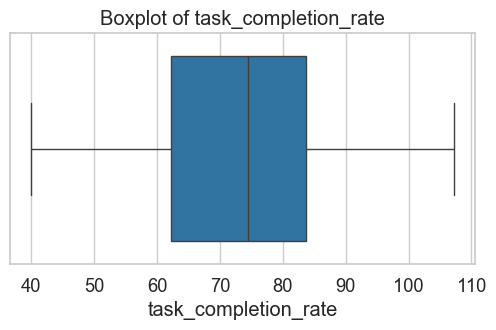

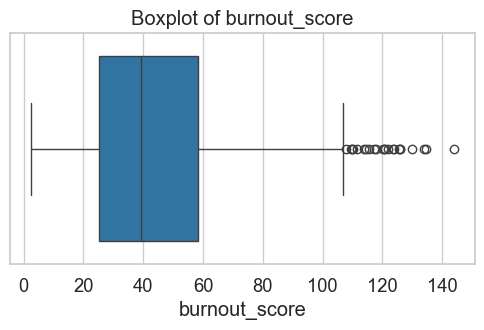

In [288]:

import matplotlib.pyplot as plt
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

# Outliers Detection and handling 

In [289]:
Q1 = df_new[num_cols].quantile(0.25)
Q3 = df_new[num_cols].quantile(0.75)
IQR = Q3- Q1

Lower_bound = Q1 - 1.5 * IQR
Upper_bound = Q3 + 1.5 * IQR

In [290]:
Lower_bound

user_id                -88.50000
work_hours              -1.69000
screen_time_hours        1.13500
meetings_count          -2.00000
breaks_taken            -1.00000
after_hours_work        -1.50000
sleep_hours              4.07500
task_completion_rate    30.20000
burnout_score          -23.87125
dtype: float64

In [291]:
Upper_bound 

user_id                 269.50000
work_hours               14.63000
screen_time_hours        17.41500
meetings_count            6.00000
breaks_taken              7.00000
after_hours_work          2.50000
sleep_hours               9.95500
task_completion_rate    115.80000
burnout_score           107.43875
dtype: float64

In [292]:
df_new.drop(columns=["user_id"], inplace=True)


In [298]:
df_new = df_new[df_new["work_hours"] >= 0]
df_new = df_new[df_new["screen_time_hours"] >= 0]
df_new = df_new[df_new["meetings_count"] >= 0]
df_new = df_new[df_new["breaks_taken"] >= 0]

In [299]:
df_new.to_csv("before_enode.csv", index=False)

# Feature Engineering 

In [300]:
df_encoded = pd.get_dummies(
    df_new,
    columns=["day_type"],
    drop_first=True
)


In [301]:
df_encoded.drop(columns=["burnout_level"], inplace=True)


In [302]:
# Split Features and Target 

In [303]:
X = df_encoded.drop(columns=["burnout_score"])
y = df_encoded["burnout_score"]


In [304]:
# Train-Test Split and Scaling 

In [305]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Models


In [306]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}


In [307]:
# models = {
#     "Linear Regression": LinearRegression(),
#     "Ridge Regression": Ridge(alpha=1.0),
#     "Lasso Regression": Lasso(alpha=0.01),
#     "Decision Tree": DecisionTreeRegressor(max_depth=6, random_state=42),
#     "Random Forest": RandomForestRegressor(
#         n_estimators=200, max_depth=10, random_state=42
#     ),
#     "Gradient Boosting": GradientBoostingRegressor(
#         n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42
#     ),
#     "SVR": SVR(kernel="rbf", C=10, gamma="scale"),
#     "KNN": KNeighborsRegressor(n_neighbors=7)
# }


In [308]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })


In [309]:
results_df = pd.DataFrame(results).sort_values(by="RMSE")
results_df


,Model,MAE,RMSE,R2
7,CatBoosting Regressor,4.760873,5.966375,0.936899
5,Random Forest Regressor,4.784705,6.082806,0.934412
0,Linear Regression,4.800197,6.134106,0.933301
2,Ridge,4.800760,6.135350,0.933274
8,AdaBoost Regressor,4.886591,6.192762,0.932020
1,Lasso,4.927089,6.315827,0.929291
6,XGBRegressor,5.167188,6.571499,0.923450
4,Decision Tree,6.857583,8.765332,0.863808
3,K-Neighbors Regressor,7.066961,9.006200,0.856221


In [310]:
best_model_name = results_df.iloc[0]["Model"]
best_rmse = results_df.iloc[0]["RMSE"]

print(f"Best Model: {best_model_name}")
print(f"Best RMSE : {best_rmse:.2f}")


Best Model: CatBoosting Regressor
Best RMSE : 5.97


In [311]:
df_new.to_csv("burn_score_data.csv", index=False)